# Deep SRQ Vectorized Rollout and SRE Batch Ablation

Runs four DeepSRQ execution cases across two scenarios and two initial SRE robustness levels:

1. Serial rollout + serial PATH SRE
2. Serial rollout + process-pool PATH SRE batching
3. Vectorized rollout with 16 envs + process-pool PATH SRE batching
4. Vectorized rollout with 32 envs + process-pool PATH SRE batching

Scenarios are `scenario1` and `scenario3`; epsilon starts are `0.25` and `0.5`; the robustness schedule is linear. This gives 16 training runs total, so each execution case is run four times.


In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np

ROOT = Path.cwd()
if ROOT.name == "bimatrix_game":
    BIMATRIX_DIR = ROOT
else:
    BIMATRIX_DIR = ROOT / "discrete_action_space" / "bimatrix_game"
DISCRETE_DIR = BIMATRIX_DIR.parent
for path in (BIMATRIX_DIR, DISCRETE_DIR):
    if str(path) not in sys.path:
        sys.path.insert(0, str(path))

from experiment_harness import (
    BASE_SEED,
    configure_path_runtime,
    run_deep_srq_ablation_variants,
    summarize_ablation_timing_rows,
)
from vectorized_deep_srq import train_vectorized_deep_srq_experiment
from stats_utils import save_training_stats


In [2]:
PATHWRAP = str(configure_path_runtime(DISCRETE_DIR))
OUTPUT_ROOT = BIMATRIX_DIR / "ablation_runs" / "vectorized_sre_batch"

SCENARIOS = ("scenario1", "scenario3")
EPSILON_STARTS = [0.5]
EPSILON_SCHEDULE = "linear"
N_EPISODES_SERIAL = 3000
N_EPISODES_VECTORIZED = 3000
USE_GPU = True

BASE_HP = {
    "sre_num_repeats": 4,
    "batch_size": 64,
    "learning_starts": 256,
    "sre_solver_workers": 4,
}

BASE_RUN_VARIANTS = (
    {"label": "serial_path_c", "mode": "serial", "solver_name": "path_c"},
    {"label": "serial_path_c_pool4", "mode": "serial", "solver_name": "path_c_pool"},
    {
        "label": "vectorized_env16_path_c_pool4",
        "mode": "vectorized",
        "solver_name": "path_c_pool",
        "trainer_kwargs": {"n_episodes": N_EPISODES_VECTORIZED, "num_envs": 16},
    },
    {
        "label": "vectorized_env32_path_c_pool4",
        "mode": "vectorized",
        "solver_name": "path_c_pool",
        "trainer_kwargs": {"n_episodes": N_EPISODES_VECTORIZED, "num_envs": 32},
    },
)

CASE_LABELS = {
    "serial_path_c": "Serial PATH",
    "serial_path_c_pool4": "Serial + PATH pool",
    "vectorized_env16_path_c_pool4": "Vectorized 16 envs",
    "vectorized_env32_path_c_pool4": "Vectorized 32 envs",
}

RUN_VARIANTS = tuple(
    {
        **variant,
        "base_label": variant["label"],
        "label": f"{variant['label']}_eps{epsilon:g}_{EPSILON_SCHEDULE}",
        "run_name_suffix": f"{variant['label']}_eps{epsilon:g}_{EPSILON_SCHEDULE}",
        "epsilon_robust_initial": epsilon,
        "epsilon_schedule": EPSILON_SCHEDULE,
    }
    for epsilon in EPSILON_STARTS
    for variant in BASE_RUN_VARIANTS
)


In [3]:
results = run_deep_srq_ablation_variants(
    variants=RUN_VARIANTS,
    scenarios=SCENARIOS,
    base_seed=BASE_SEED,
    pathwrap_path=PATHWRAP,
    output_root=OUTPUT_ROOT,
    use_gpu=USE_GPU,
    write_plots=False,
    default_n_episodes=N_EPISODES_SERIAL,
    default_epsilon_schedule=EPSILON_SCHEDULE,
    default_hyperparameter_overrides=BASE_HP,
    mode_trainers={"vectorized": train_vectorized_deep_srq_experiment},
)

save_training_stats(OUTPUT_ROOT / "vectorized_sre_batch_manifest.txt", results)


Deep SRQ Scenario 1 | DeepSRQ vs DeepSRQ | eps0=0.5 | schedule=linear | solver=path_c | seed=2025


scenario1:eps0.5_linear__serial_path_c_eps0.5_linear:path_c: 100%|██████████| 3000/3000 [1:07:27<00:00,  1.35s/it]

Saved stats to /home/wowthecoder/SRE-DQN/discrete_action_space/bimatrix_game/ablation_runs/vectorized_sre_batch/serial_path_c_eps0.5_linear/scenario1/deepsrq_vs_deepsrq__eps0.5_linear__serial_path_c_eps0.5_linear/training_stats.txt
Scenario 1 - DeepSRQ vs DeepSRQ - eps0.5_linear__serial_path_c_eps0.5_linear
Wall clock: 4409.255s (73.49 min)
Episode time:   count=3000, mean=1.468997s (1468997.39 us), min=0.000956s, max=24.074667s, std=1.589934s
SRE solve time: count=359519, mean=0.011838s (11837.63 us), min=0.007084s, max=0.080173s, std=0.002271s
Backend solve:  count=7190380, mean=0.000508s (508.19 us), min=0.000126s, max=0.169870s, std=0.000668s
  Agent 0 (DuelingDoubleDqnSreAgent)
    SRE solve:  count=359519, mean=0.011838s (11837.63 us), min=0.007084s, max=0.080173s, std=0.002271s
    Backend:    count=7190380, mean=0.000508s (508.19 us), min=0.000126s, max=0.169870s, std=0.000668s
    Update:     count=11540, mean=0.350489s (350489.40 us), min=0.165631s, max=1.653673s, std=0.08572

Deep SRQ Scenario 1 | DeepSRQ vs DeepSRQ | eps0=0.5 | schedule=linear | solver=path_c_pool | seed=2026


scenario1:eps0.5_linear__serial_path_c_pool4_eps0.5_linear:path_c_pool: 100%|██████████| 3000/3000 [27:55<00:00,  1.79it/s] 

...


scenario3:vectorized_envs16_eps0.5_linear__vectorized_env16_path_c_pool4_eps0.5_linear: 100%|██████████| 3000/3000 [42:18<00:00,  1.18it/s] 

Scenario 3 - vectorized DeepSRQ
Wall clock: 2538.933s (42.32 min)
Episode time:   count=0
SRE solve time: count=774921, mean=0.003062s (3062.32 us), min=0.002140s, max=0.018648s, std=0.000444s
Backend solve:  count=774921, mean=0.010964s (10964.01 us), min=0.006164s, max=0.222575s, std=0.004450s
  Agent 0 (DuelingDoubleDqnSreAgent)
    SRE solve:  count=774921, mean=0.003062s (3062.32 us), min=0.002140s, max=0.018648s, std=0.000444s
    Backend:    count=774921, mean=0.010964s (10964.01 us), min=0.006164s, max=0.222575s, std=0.004450s
    Update:     count=16693, mean=0.139066s (139066.05 us), min=0.076492s, max=0.417186s, std=0.025323s

Reward Summary
Scenario   | Pair               | Agent             | Mean  | Std    | Mean (Last 1000) | Std (Last 1000) | Episodes
-----------+--------------------+-------------------+-------+--------+------------------+-----------------+---------
Scenario 3 | DeepSRQ vs DeepSRQ | Agent 1 (DeepSRQ) | 44.52 | 113.25 | 82.93            | 36.43          


scenario3:vectorized_envs32_eps0.5_linear__vectorized_env32_path_c_pool4_eps0.5_linear: 100%|██████████| 3000/3000 [39:50<00:00,  1.26it/s] 

Scenario 3 - vectorized DeepSRQ
Wall clock: 2390.021s (39.83 min)
Episode time:   count=0
SRE solve time: count=724629, mean=0.003089s (3088.60 us), min=0.002146s, max=0.016597s, std=0.000378s
Backend solve:  count=724629, mean=0.011072s (11072.13 us), min=0.005941s, max=0.209639s, std=0.004472s
  Agent 0 (DuelingDoubleDqnSreAgent)
    SRE solve:  count=724629, mean=0.003089s (3088.60 us), min=0.002146s, max=0.016597s, std=0.000378s
    Backend:    count=724629, mean=0.011072s (11072.13 us), min=0.005941s, max=0.209639s, std=0.004472s
    Update:     count=15961, mean=0.138298s (138298.01 us), min=0.049974s, max=0.372974s, std=0.023788s

Reward Summary
Scenario   | Pair               | Agent             | Mean  | Std    | Mean (Last 1000) | Std (Last 1000) | Episodes
-----------+--------------------+-------------------+-------+--------+------------------+-----------------+---------
Scenario 3 | DeepSRQ vs DeepSRQ | Agent 1 (DeepSRQ) | 43.02 | 116.97 | 80.41            | 40.85          

PosixPath('/home/wowthecoder/SRE-DQN/discrete_action_space/bimatrix_game/ablation_runs/vectorized_sre_batch/vectorized_sre_batch_manifest.txt')

In [4]:
def _base_variant_label(label):
    return label.rsplit("_eps", 1)[0]


def _fmt(value, kind):
    if value is None:
        return "-"
    if kind == "int":
        return f"{int(value):,}"
    if kind == "float1":
        return f"{float(value):,.1f}"
    if kind == "float2":
        return f"{float(value):,.2f}"
    return str(value)


def print_pretty_table(rows, columns):
    rendered = []
    headers = [title for _, title, _ in columns]
    for row in rows:
        rendered.append([_fmt(row.get(key), kind) for key, _, kind in columns])
    widths = [len(header) for header in headers]
    for row in rendered:
        widths = [max(width, len(value)) for width, value in zip(widths, row)]
    header_line = " | ".join(header.ljust(width) for header, width in zip(headers, widths))
    separator = "-+-".join("-" * width for width in widths)
    print(header_line)
    print(separator)
    for row in rendered:
        print(" | ".join(value.ljust(width) for value, width in zip(row, widths)))


summary_rows = []
for row in summarize_ablation_timing_rows(results):
    stats = results[row["scenario"]][row["variant"]]
    base_label = _base_variant_label(row["variant"])
    summary_rows.append({
        **row,
        "case": CASE_LABELS.get(base_label, base_label),
        "epsilon": stats["epsilon_robust_initial"],
        "schedule": stats["epsilon_schedule"],
    })

summary_rows.sort(key=lambda row: (row["scenario"], row["epsilon"], row["case"]))

print_pretty_table(
    summary_rows,
    columns=(
        ("scenario", "Scenario", "str"),
        ("epsilon", "Eps0", "float2"),
        ("schedule", "Schedule", "str"),
        ("case", "Case", "str"),
        ("mode", "Mode", "str"),
        ("env_steps", "Env Steps", "int"),
        ("wall_seconds", "Wall s", "float1"),
        ("steps_per_second", "Steps/s", "float2"),
        ("mean_sre_ms", "SRE ms", "float2"),
        ("mean_backend_ms", "Backend ms", "float2"),
        ("agent1_mean_last", "A1 Last", "float2"),
        ("agent2_mean_last", "A2 Last", "float2"),
    ),
)


Scenario  | Eps0 | Schedule | Case               | Mode       | Env Steps | Wall s  | Steps/s | SRE ms | Backend ms | A1 Last | A2 Last
----------+------+----------+--------------------+------------+-----------+---------+---------+--------+------------+---------+--------
scenario1 | 0.50 | linear   | Serial + PATH pool | serial     | 46,242    | 1,824.7 | 25.34   | 4.40   | 13.09      | 81.59   | 83.92  
scenario1 | 0.50 | linear   | Serial PATH        | serial     | 46,414    | 4,409.3 | 10.53   | 11.84  | 0.51       | 85.18   | 87.86  
scenario1 | 0.50 | linear   | Vectorized 16 envs | vectorized | 48,048    | 1,459.4 | 32.92   | 3.44   | 12.00      | 80.40   | 83.44  
scenario1 | 0.50 | linear   | Vectorized 32 envs | vectorized | 44,480    | 1,231.0 | 36.13   | 3.21   | 11.30      | 77.53   | 78.11  
scenario3 | 0.50 | linear   | Serial + PATH pool | serial     | 66,643    | 2,852.3 | 23.36   | 3.48   | 11.07      | 81.70   | 82.49  
scenario3 | 0.50 | linear   | Serial PATH       

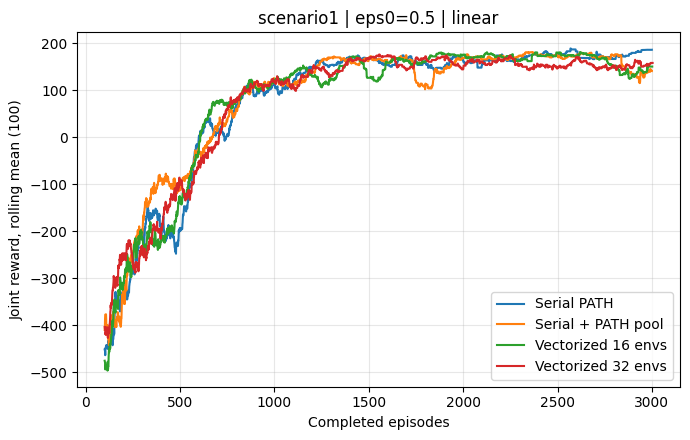

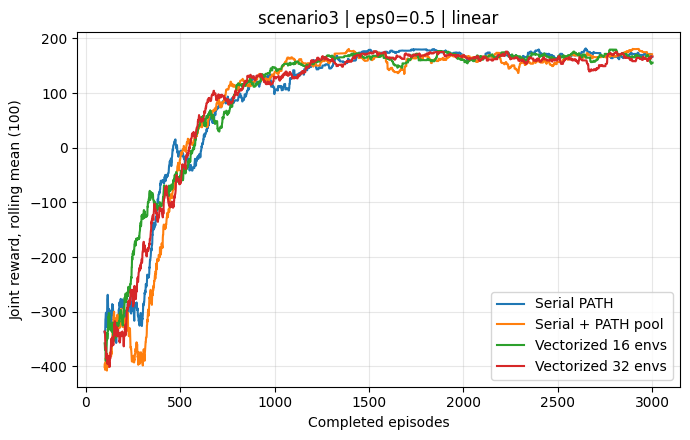

In [5]:
def rolling_mean(values, window=100):
    values = np.asarray(values, dtype=float)
    if values.size == 0:
        return values
    window = max(1, min(int(window), values.size))
    kernel = np.ones(window, dtype=float) / window
    return np.convolve(values, kernel, mode="valid")


ROLLING_WINDOW = 100

for scenario_key in SCENARIOS:
    fig, axes = plt.subplots(1, len(EPSILON_STARTS), figsize=(7 * len(EPSILON_STARTS), 4.5), sharey=True)
    axes = np.atleast_1d(axes)
    for ax, epsilon in zip(axes, EPSILON_STARTS):
        for base_variant in BASE_RUN_VARIANTS:
            label = f"{base_variant['label']}_eps{epsilon:g}_{EPSILON_SCHEDULE}"
            stats = results[scenario_key][label]
            rewards = stats["rewards"]
            min_len = min(len(rewards[0]), len(rewards[1]))
            if min_len == 0:
                continue
            joint_reward = np.asarray(rewards[0][:min_len], dtype=float) + np.asarray(rewards[1][:min_len], dtype=float)
            smoothed = rolling_mean(joint_reward, window=ROLLING_WINDOW)
            x = np.arange(smoothed.size) + min(ROLLING_WINDOW, joint_reward.size)
            ax.plot(x, smoothed, label=CASE_LABELS[base_variant["label"]])
        ax.set_title(f"{scenario_key} | eps0={epsilon:g} | {EPSILON_SCHEDULE}")
        ax.set_xlabel("Completed episodes")
        ax.grid(True, alpha=0.3)
    axes[0].set_ylabel(f"Joint reward, rolling mean ({ROLLING_WINDOW})")
    axes[-1].legend(loc="best")
    fig.tight_layout()
    plt.show()
